# MNIST Bandit Classification — Clean Comparison

Five methods compared on MNIST under **bandit feedback** (binary 0/1 reward per sampled action):

| Method | Description |
|---|---|
| `ce` | Cross-entropy with full labels (oracle upper bound) |
| `pg` | Policy Gradient (REINFORCE + expected-reward baseline) |
| `dg` | Delightful PG (sigmoid-gated PG, η=1) |
| `entropy_hv` | PG + exact entropy bonus: loss = PG − β·H(π) |
| `entropy_lv` | PG + score-function entropy estimator (DistG-style) |

**Protocol**
- Data: 59 000 train / 1 000 val / 10 000 test
- Hyperparameter sweep: 1 seed; pick best config per method by **final val accuracy**
- Final run: 5 seeds with best config; report mean ± stderr

In [1]:
import math
import itertools
import torch
import matplotlib.pyplot as plt

from data  import load_mnist_split
from train import train_run

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


In [2]:
# ── Global seeds ────────────────────────────────────────────────────────────
DATA_SEED   = 42    # fixes the 59k/1k train-val split (never changes)
SWEEP_SEED  = 0     # single seed used during hparam sweep
FINAL_SEEDS = list(range(5))   # seeds for the final multi-seed run

# ── Shared training config  (matches original MNIST.ipynb) ──────────────────
BASE_CFG = dict(
    hidden_sizes     = (50, 50),
    batch_size       = 100,
    train_steps      = 10_000,
    eval_every       = 200,
    eta              = 1.0,        # DG temperature (fixed)
    baseline_mode    = "expected",
    samples_per_image= 1,
    device           = DEVICE,
)

# ── Hyperparameter grids ────────────────────────────────────────────────────
LR_VALUES   = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
BETA_VALUES = [1e-2, 3e-2, 1e-1, 3e-1, 1e0]

METHODS_NO_BETA   = ["ce", "pg", "dg"]
METHODS_WITH_BETA = ["entropy_hv", "entropy_lv"]
ALL_METHODS       = METHODS_NO_BETA + METHODS_WITH_BETA

In [3]:
# ── Load data ───────────────────────────────────────────────────────────────
x_train, y_train, x_val, y_val, x_test, y_test = load_mnist_split(
    val_size=1000, seed=DATA_SEED
)
print(f"Train: {len(x_train):,}  |  Val: {len(x_val):,}  |  Test: {len(x_test):,}")

Train: 59,000  |  Val: 1,000  |  Test: 10,000


## Hyperparameter Sweep  (1 seed)

- `ce`, `pg`, `dg`: sweep **lr** only (5 values)
- `entropy_hv`, `entropy_lv`: sweep **lr × beta** (5 × 5 = 25 configs each)

Best config selected by **final validation accuracy** (step 10 000).

In [4]:
sweep_results = {m: {} for m in ALL_METHODS}

# ── Methods without beta ────────────────────────────────────────────────────
for method in METHODS_NO_BETA:
    for lr in LR_VALUES:
        print(f"[sweep] {method:12s}  lr={lr:.0e}")
        sweep_results[method][lr] = train_run(
            method=method, seed=SWEEP_SEED,
            x_train=x_train, y_train=y_train,
            x_val=x_val,     y_val=y_val,
            x_test=x_test,   y_test=y_test,
            lr=lr, **BASE_CFG,
        )

# ── Methods with beta ───────────────────────────────────────────────────────
for method in METHODS_WITH_BETA:
    for lr, beta in itertools.product(LR_VALUES, BETA_VALUES):
        print(f"[sweep] {method:12s}  lr={lr:.0e}  beta={beta:.0e}")
        sweep_results[method][(lr, beta)] = train_run(
            method=method, seed=SWEEP_SEED,
            x_train=x_train, y_train=y_train,
            x_val=x_val,     y_val=y_val,
            x_test=x_test,   y_test=y_test,
            lr=lr, beta=beta, **BASE_CFG,
        )

print("\nSweep complete.")

[sweep] ce            lr=1e-04
[sweep] ce            lr=3e-04
[sweep] ce            lr=1e-03
[sweep] ce            lr=3e-03
[sweep] ce            lr=1e-02
[sweep] pg            lr=1e-04
[sweep] pg            lr=3e-04
[sweep] pg            lr=1e-03
[sweep] pg            lr=3e-03
[sweep] pg            lr=1e-02
[sweep] dg            lr=1e-04
[sweep] dg            lr=3e-04
[sweep] dg            lr=1e-03
[sweep] dg            lr=3e-03
[sweep] dg            lr=1e-02
[sweep] entropy_hv    lr=1e-04  beta=1e-02
[sweep] entropy_hv    lr=1e-04  beta=3e-02
[sweep] entropy_hv    lr=1e-04  beta=1e-01
[sweep] entropy_hv    lr=1e-04  beta=3e-01
[sweep] entropy_hv    lr=1e-04  beta=1e+00
[sweep] entropy_hv    lr=3e-04  beta=1e-02
[sweep] entropy_hv    lr=3e-04  beta=3e-02
[sweep] entropy_hv    lr=3e-04  beta=1e-01
[sweep] entropy_hv    lr=3e-04  beta=3e-01
[sweep] entropy_hv    lr=3e-04  beta=1e+00
[sweep] entropy_hv    lr=1e-03  beta=1e-02
[sweep] entropy_hv    lr=1e-03  beta=3e-02
[sweep] entropy_hv 

In [5]:
# ── Select best hparams per method (final val accuracy) ─────────────────────
best_hparams = {}

for method in METHODS_NO_BETA:
    best_lr = max(LR_VALUES,
                  key=lambda lr: sweep_results[method][lr]["val_accs"][-1].item())
    best_hparams[method] = {"lr": best_lr}

for method in METHODS_WITH_BETA:
    keys     = list(itertools.product(LR_VALUES, BETA_VALUES))
    best_key = max(keys,
                   key=lambda k: sweep_results[method][k]["val_accs"][-1].item())
    best_hparams[method] = {"lr": best_key[0], "beta": best_key[1]}

print("Best hyperparameters (by final val accuracy after sweep):")
print("-" * 50)
for method, hp in best_hparams.items():
    parts = [f"lr={hp['lr']:.0e}"]
    if "beta" in hp:
        parts.append(f"beta={hp['beta']:.0e}")
    print(f"  {method:15s}: {', '.join(parts)}")

Best hyperparameters (by final val accuracy after sweep):
--------------------------------------------------
  ce             : lr=3e-03
  pg             : lr=1e-03
  dg             : lr=1e-03
  entropy_hv     : lr=1e-03, beta=3e-01
  entropy_lv     : lr=1e-03, beta=3e-01


## Final Run  (5 seeds, best hparams per method)

In [9]:
final_results = {}
n_seeds = len(FINAL_SEEDS)

def _collect_runs(method, hp):
    """Run *method* with hparams *hp* over FINAL_SEEDS; return aggregated dict."""
    hp_str = ", ".join(f"{k}={v:.0e}" for k, v in hp.items())
    print(f"\n=== {method.upper():12s} | {hp_str} ===")
    runs_val, runs_test, shared_steps = [], [], None
    for seed in FINAL_SEEDS:
        result = train_run(
            method=method, seed=seed,
            x_train=x_train, y_train=y_train,
            x_val=x_val,     y_val=y_val,
            x_test=x_test,   y_test=y_test,
            **{**BASE_CFG, **hp},
        )
        shared_steps = result["steps"]
        runs_val.append(result["val_accs"])
        runs_test.append(result["test_accs"])
        print(
            f"  seed={seed}  "
            f"val={result['val_accs'][-1]:.4f}  "
            f"test={result['test_accs'][-1]:.4f}"
        )
    runs_val  = torch.stack(runs_val)
    runs_test = torch.stack(runs_test)
    return {
        "steps"      : shared_steps,
        "val_accs"   : runs_val,
        "test_accs"  : runs_test,
        "val_mean"   : runs_val.mean(0),
        "val_stderr" : runs_val.std(0, unbiased=True) / math.sqrt(n_seeds),
        "test_mean"  : runs_test.mean(0),
        "test_stderr": runs_test.std(0, unbiased=True) / math.sqrt(n_seeds),
    }

# ── All methods at their best hparams ───────────────────────────────────────
for method in ALL_METHODS: 
    final_results[method] = _collect_runs(method, best_hparams[method])

# ── CE also at lr=1e-3 (shared lr with all bandit methods, for fair plot) ───
final_results["ce_1e3"] = _collect_runs("ce", {"lr": 1e-3})

print("\nFinal runs complete.")


=== CE           | lr=3e-03 ===
  seed=0  val=0.9780  test=0.9759
  seed=1  val=0.9710  test=0.9676
  seed=2  val=0.9790  test=0.9722
  seed=3  val=0.9640  test=0.9729
  seed=4  val=0.9730  test=0.9738

=== PG           | lr=1e-03 ===
  seed=0  val=0.9510  test=0.9590
  seed=1  val=0.9510  test=0.9579
  seed=2  val=0.9480  test=0.9525
  seed=3  val=0.9440  test=0.9497
  seed=4  val=0.9440  test=0.9454

=== DG           | lr=1e-03 ===
  seed=0  val=0.9680  test=0.9683
  seed=1  val=0.9610  test=0.9654
  seed=2  val=0.9600  test=0.9678
  seed=3  val=0.9580  test=0.9653
  seed=4  val=0.9590  test=0.9675

=== ENTROPY_HV   | lr=1e-03, beta=3e-01 ===
  seed=0  val=0.9650  test=0.9683
  seed=1  val=0.9570  test=0.9651
  seed=2  val=0.9610  test=0.9644
  seed=3  val=0.9650  test=0.9670
  seed=4  val=0.9640  test=0.9680

=== ENTROPY_LV   | lr=1e-03, beta=3e-01 ===
  seed=0  val=0.9700  test=0.9716
  seed=1  val=0.9690  test=0.9692
  seed=2  val=0.9700  test=0.9715
  seed=3  val=0.9620  test=0.

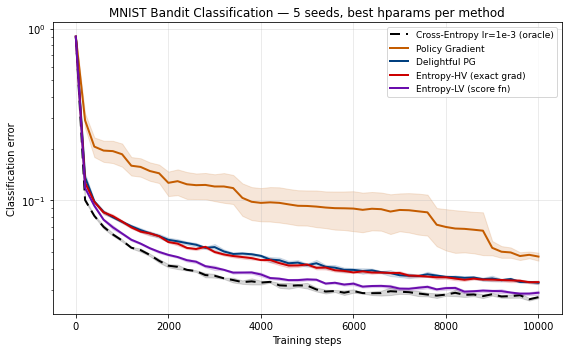

In [12]:
# ── Plot ─────────────────────────────────────────────────────────────────────
# CE is plotted at lr=1e-3 (shared lr) with a dotted line for visual separation.
# Colors: PG=dark orange, DG=dark blue, entropy_hv=red, entropy_lv=purple.
COLORS = {
    "ce_1e3"     : "black",
    "pg"         : "#c45c00",   # dark orange
    "dg"         : "#003f7f",   # dark blue
    "entropy_hv" : "#cc0000",   # red
    "entropy_lv" : "#6a0dad",   # purple
}
LABELS = {
    "ce_1e3"     : "Cross-Entropy lr=1e-3 (oracle)",
    "pg"         : "Policy Gradient",
    "dg"         : "Delightful PG",
    "entropy_hv" : "Entropy-HV (exact grad)",
    "entropy_lv" : "Entropy-LV (score fn)",
}
LINESTYLES = {
    "ce_1e3"     : (0, (5, 3)),  # dashed
    "pg"         : "solid",
    "dg"         : "solid",
    "entropy_hv" : "solid",
    "entropy_lv" : "solid",
}

PLOT_METHODS = ["ce_1e3", "pg", "dg", "entropy_hv", "entropy_lv"]

fig, ax = plt.subplots(figsize=(8, 5))

for method in PLOT_METHODS:
    res    = final_results[method]
    steps  = res["steps"].numpy()
    mean   = 1.0 - res["test_mean"].numpy()
    stderr = res["test_stderr"].numpy()
    ax.plot(steps, mean,
            label=LABELS[method],
            color=COLORS[method],
            linestyle=LINESTYLES[method],
            linewidth=2)
    ax.fill_between(steps, mean - stderr, mean + stderr,
                    color=COLORS[method], alpha=0.15)

ax.set_yscale("log")
ax.set_xlabel("Training steps")
ax.set_ylabel("Classification error")
ax.set_title(f"MNIST Bandit Classification — {n_seeds} seeds, best hparams per method")
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [13]:
# ── Summary ──────────────────────────────────────────────────────────────────
print("=" * 62)
print("BEST HYPERPARAMETERS  (selected by final val accuracy, sweep)")
print("=" * 62)
for method, hp in best_hparams.items():
    parts = [f"lr={hp['lr']:.0e}"]
    if "beta" in hp:
        parts.append(f"beta={hp['beta']:.0e}")
    print(f"  {method:15s}: {', '.join(parts)}")

print()
print("=" * 55)
print(f"FINAL TEST RESULTS  (mean ± stderr over {n_seeds} seeds)")
print("=" * 55)
for method in ALL_METHODS:
    res   = final_results[method]
    t_err = 1.0 - res["test_mean"][-1].item()
    t_se  = res["test_stderr"][-1].item()
    print(f"  {method:15s}: test_err={t_err:.4f}±{t_se:.4f}")

# CE at lr=1e-3 (the curve shown in the plot)
res   = final_results["ce_1e3"]
t_err = 1.0 - res["test_mean"][-1].item()
t_se  = res["test_stderr"][-1].item()
print(f"  {'ce (lr=1e-3)':15s}: test_err={t_err:.4f}±{t_se:.4f}  (plotted)")

BEST HYPERPARAMETERS  (selected by final val accuracy, sweep)
  ce             : lr=3e-03
  pg             : lr=1e-03
  dg             : lr=1e-03
  entropy_hv     : lr=1e-03, beta=3e-01
  entropy_lv     : lr=1e-03, beta=3e-01

FINAL TEST RESULTS  (mean ± stderr over 5 seeds)
  ce             : test_err=0.0275±0.0014
  pg             : test_err=0.0471±0.0025
  dg             : test_err=0.0331±0.0006
  entropy_hv     : test_err=0.0334±0.0008
  entropy_lv     : test_err=0.0290±0.0009
  ce (lr=1e-3)   : test_err=0.0273±0.0003  (plotted)


In [14]:
final_results

{'ce': {'steps': tensor([    0,   200,   400,   600,   800,  1000,  1200,  1400,  1600,  1800,
           2000,  2200,  2400,  2600,  2800,  3000,  3200,  3400,  3600,  3800,
           4000,  4200,  4400,  4600,  4800,  5000,  5200,  5400,  5600,  5800,
           6000,  6200,  6400,  6600,  6800,  7000,  7200,  7400,  7600,  7800,
           8000,  8200,  8400,  8600,  8800,  9000,  9200,  9400,  9600,  9800,
          10000]),
  'val_accs': tensor([[0.0800, 0.9160, 0.9350, 0.9480, 0.9520, 0.9460, 0.9580, 0.9520, 0.9520,
           0.9600, 0.9560, 0.9470, 0.9620, 0.9670, 0.9640, 0.9630, 0.9670, 0.9640,
           0.9620, 0.9630, 0.9680, 0.9680, 0.9670, 0.9690, 0.9670, 0.9680, 0.9680,
           0.9700, 0.9710, 0.9680, 0.9670, 0.9740, 0.9670, 0.9750, 0.9660, 0.9650,
           0.9670, 0.9690, 0.9690, 0.9660, 0.9680, 0.9690, 0.9670, 0.9700, 0.9680,
           0.9650, 0.9710, 0.9730, 0.9740, 0.9690, 0.9780],
          [0.1140, 0.9130, 0.9290, 0.9490, 0.9510, 0.9500, 0.9480, 0.9550, 0.95